In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import linprog
%matplotlib inline


In [10]:
path = 'data\monthly_ROR_full.csv'

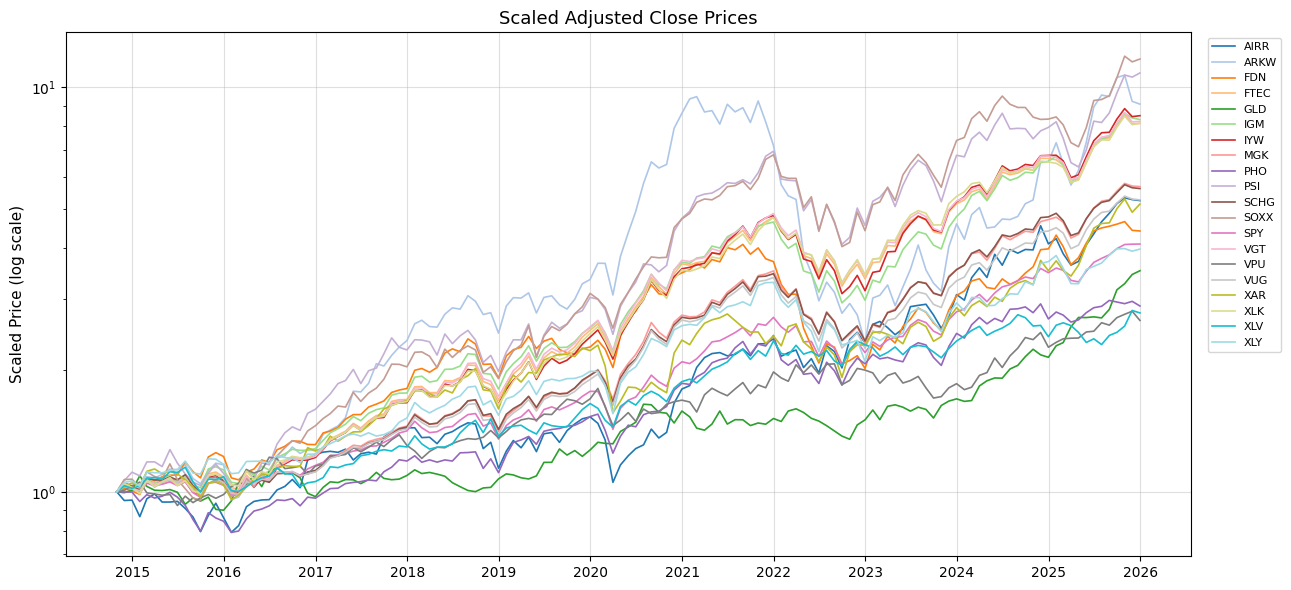

In [11]:
# ── Load data ──────────────────────────────────────────────────────────────────
# R_train is assets × months (book convention).
# We need months × assets for pandas plotting, so we transpose.
R_train = pd.read_csv(path, index_col=0)   # n × T
monthly_ROR = R_train.T                                             # T × n
monthly_ROR.index = pd.to_datetime(monthly_ROR.index)

tickers = list(monthly_ROR.columns)
n = len(tickers)

# ── Reconstruct scaled price series from returns ───────────────────────────────
# p_scaled[0] = 1 for every asset; p_scaled[t] = prod(1 + r_1 ... r_t)
prices_scaled = (1 + monthly_ROR).cumprod()
prices_scaled = prices_scaled.div(prices_scaled.iloc[0])           # normalise to 1

# ── Plot ───────────────────────────────────────────────────────────────────────
colors = plt.cm.tab20(np.linspace(0, 1, n))

fig, ax = plt.subplots(figsize=(13, 6))

for i, tkr in enumerate(tickers):
    ax.plot(prices_scaled.index, prices_scaled[tkr],
            lw=1.2, color=colors[i], label=tkr)

ax.set_yscale("log")
ax.set_title("Scaled Adjusted Close Prices",
             fontsize=13)
ax.set_ylabel("Scaled Price (log scale)", fontsize=11)
ax.legend(bbox_to_anchor=(1.01, 1.0), loc="upper left", fontsize=8, ncol=1)
ax.grid(True, alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
fig.tight_layout()
plt.show()

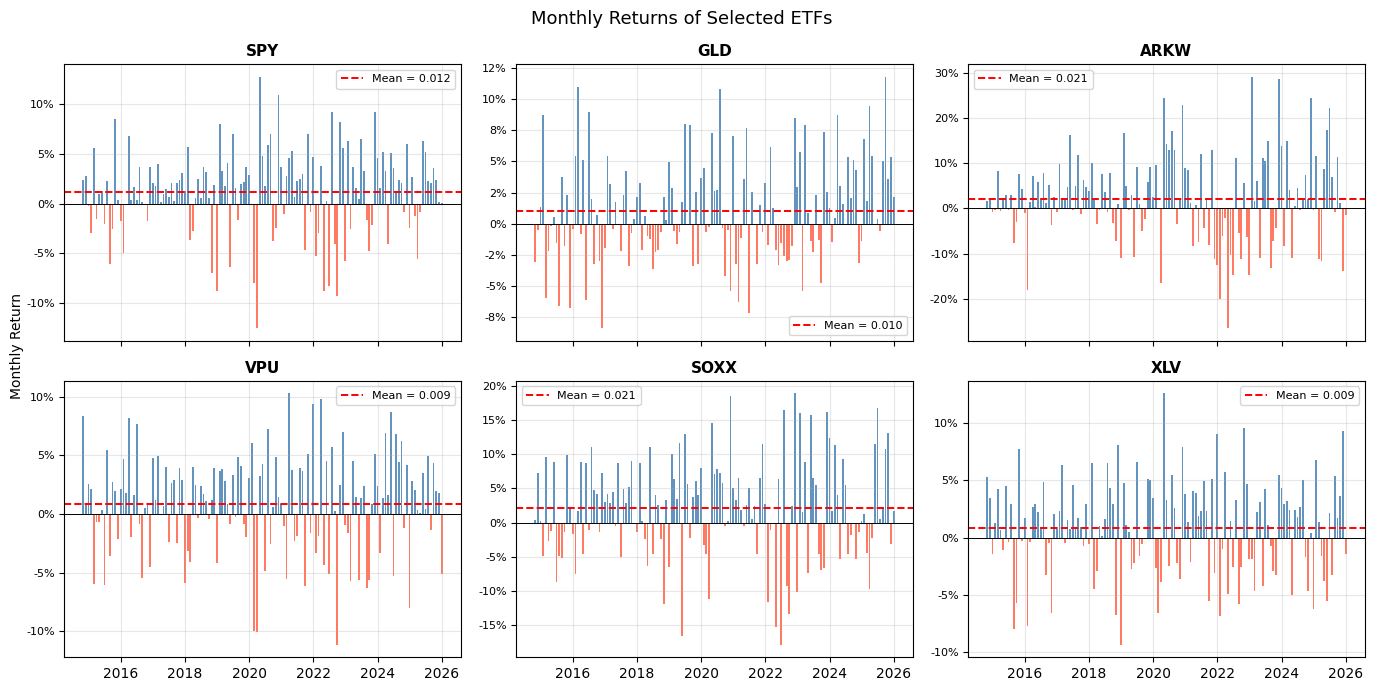

In [12]:
# ── Load data ──────────────────────────────────────────────────────────────────
R_train = pd.read_csv(path, index_col=0)
monthly_ROR = R_train.T
monthly_ROR.index = pd.to_datetime(monthly_ROR.index)

# ── Choose which ETFs to highlight (edit freely) ───────────────────────────────
highlight = ["SPY", "GLD", "ARKW", "VPU", "SOXX", "XLV"]

mean_ret = monthly_ROR.mean()

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
axes = axes.flatten()

for i, tkr in enumerate(highlight):
    bar_colors = ["tomato" if v < 0 else "steelblue"
                  for v in monthly_ROR[tkr]]
    axes[i].bar(monthly_ROR.index, monthly_ROR[tkr],
                width=20, color=bar_colors, alpha=0.85)
    axes[i].axhline(0, color="black", lw=0.7)
    axes[i].axhline(mean_ret[tkr], color="red", lw=1.4, ls="--",
                    label=f"Mean = {mean_ret[tkr]:.3f}")
    axes[i].set_title(tkr, fontsize=11, fontweight="bold")
    axes[i].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    axes[i].tick_params(axis="y", labelsize=8)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=8)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axes[i].xaxis.set_major_locator(mdates.YearLocator(2))

fig.suptitle("Monthly Returns of Selected ETFs",
             fontsize=13)
fig.supylabel("Monthly Return", fontsize=10)
fig.tight_layout()
plt.show()


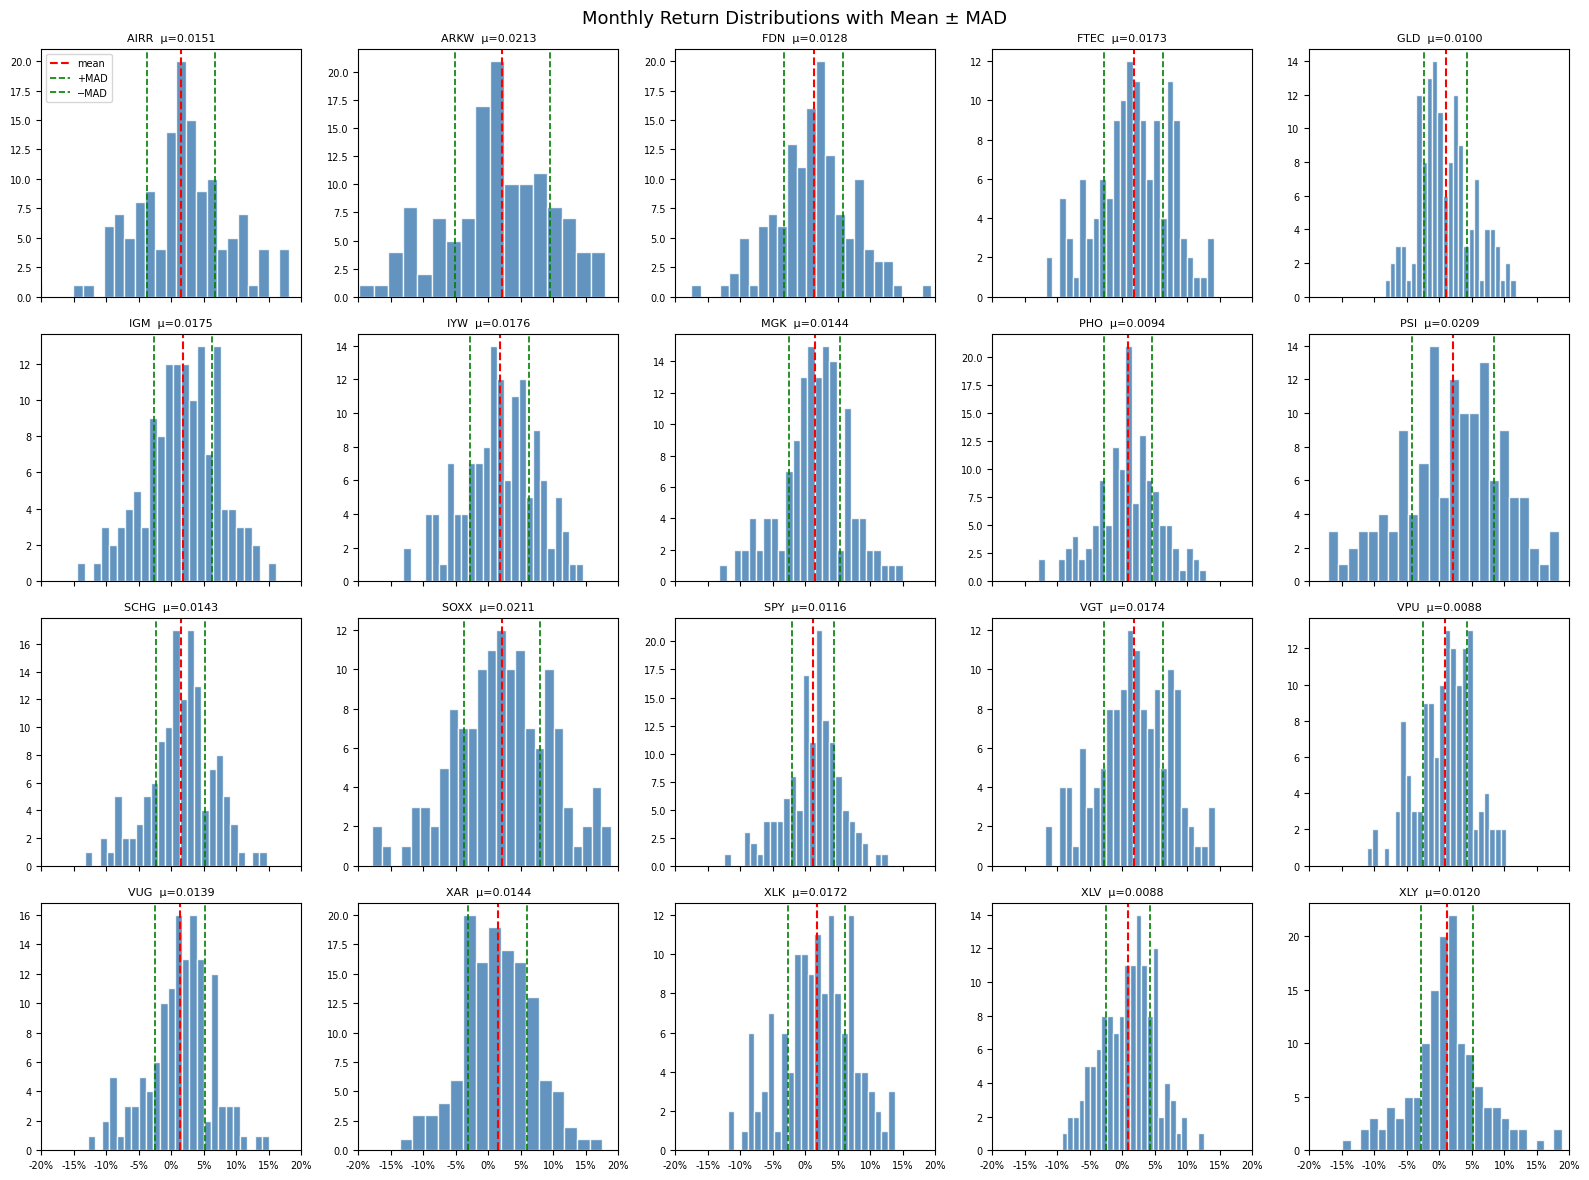

In [13]:
# ── Load data ──────────────────────────────────────────────────────────────────
R_train = pd.read_csv(path, index_col=0)
monthly_ROR = R_train.T
monthly_ROR.index = pd.to_datetime(monthly_ROR.index)

tickers  = list(monthly_ROR.columns)
mean_ret = monthly_ROR.mean()
mad_ind  = (monthly_ROR - mean_ret).abs().mean()   # MAD per asset

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 5, figsize=(16, 12), sharex=True, sharey=False)
axes = axes.flatten()

for i, tkr in enumerate(tickers):
    mu_i  = mean_ret[tkr]
    mad_i = mad_ind[tkr]

    axes[i].hist(monthly_ROR[tkr], bins=25,
                 color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].axvline(mu_i,          color="red",   ls="--", lw=1.5,
                    label="mean")
    axes[i].axvline(mu_i + mad_i,  color="green", ls="--", lw=1.2,
                    label="+MAD")
    axes[i].axvline(mu_i - mad_i,  color="green", ls="--", lw=1.2,
                    label="−MAD")
    axes[i].set_title(f"{tkr}  μ={mu_i:.4f}", fontsize=8)
    axes[i].tick_params(labelsize=7)
    axes[i].set_xlim(-0.20, 0.20)
    axes[i].xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

# Legend on first panel only
axes[0].legend(fontsize=7, loc="upper left")

fig.suptitle(
    "Monthly Return Distributions with Mean ± MAD",
    fontsize=13)
fig.tight_layout()
plt.show()

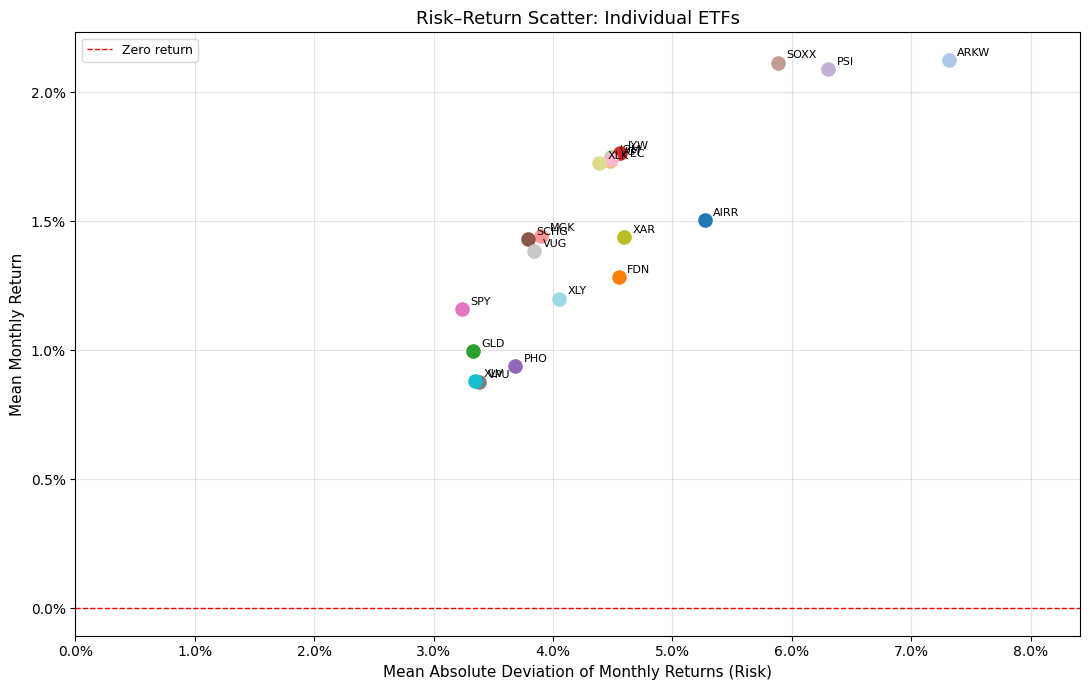

In [14]:
# ── Load data ──────────────────────────────────────────────────────────────────
R_train = pd.read_csv(path, index_col=0)
monthly_ROR = R_train.T
monthly_ROR.index = pd.to_datetime(monthly_ROR.index)

tickers  = list(monthly_ROR.columns)
n        = len(tickers)
mean_ret = monthly_ROR.mean()
mad_ind  = (monthly_ROR - mean_ret).abs().mean()

# ── Plot ───────────────────────────────────────────────────────────────────────
colors = plt.cm.tab20(np.linspace(0, 1, n))

fig, ax = plt.subplots(figsize=(11, 7))

for i, tkr in enumerate(tickers):
    ax.scatter(mad_ind[tkr], mean_ret[tkr],
               s=90, color=colors[i], zorder=3)
    ax.annotate(tkr, (mad_ind[tkr], mean_ret[tkr]),
                textcoords="offset points", xytext=(6, 3), fontsize=8)

ax.axhline(0, color="red", ls="--", lw=1, label="Zero return")
ax.set_xlabel("Mean Absolute Deviation of Monthly Returns (Risk)",
              fontsize=11)
ax.set_ylabel("Mean Monthly Return", fontsize=11)
ax.set_title("Risk–Return Scatter: Individual ETFs",
             fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
ax.set_xlim(0, mad_ind.max() * 1.15)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.35)

fig.tight_layout()
plt.show()

Frontier points computed: 37


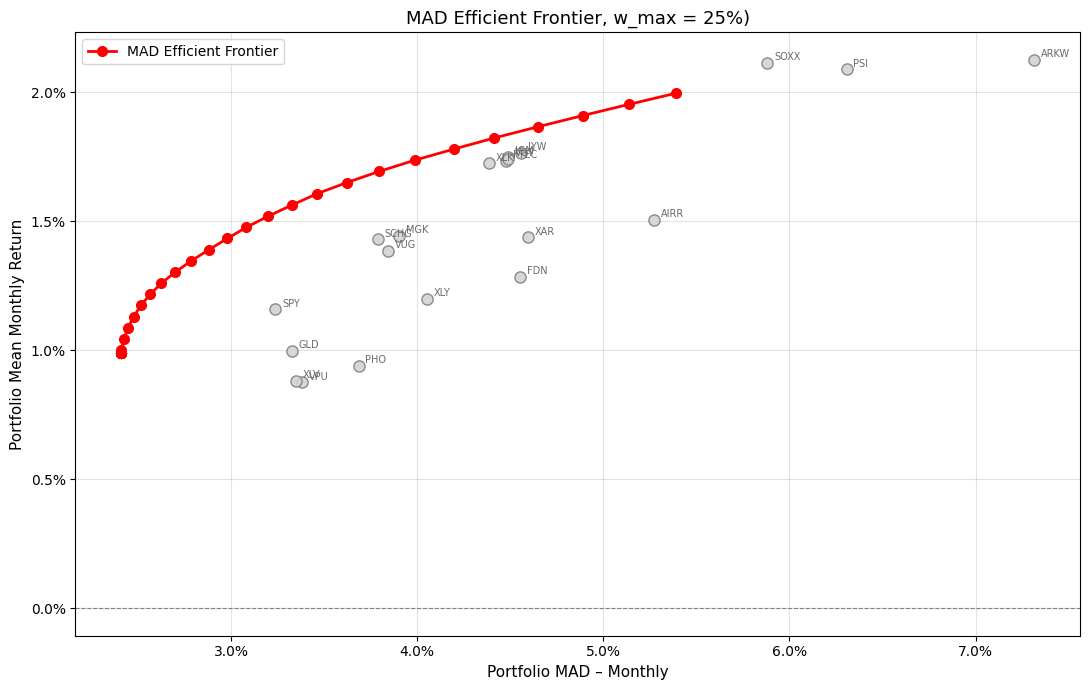

In [15]:
# ── Load data ──────────────────────────────────────────────────────────────────
R_train = pd.read_csv(path, index_col=0)
monthly_ROR = R_train.T
monthly_ROR.index = pd.to_datetime(monthly_ROR.index)

tickers  = list(monthly_ROR.columns)
n        = len(tickers)
mean_ret = monthly_ROR.mean()
mad_ind  = (monthly_ROR - mean_ret).abs().mean()

# ── MAD solver ────────────────────────────────────────────────────────────────
def solve_mad(returns_df, mu_bar, w_max=0.25):
    R   = returns_df.values      # T × n
    T, n = R.shape
    mu  = R.mean(axis=0)         # expected return per asset
    p   = np.ones(T) / T         # equal probability per scenario

    # Objective: minimise sum p_t * d_t
    c = np.concatenate([np.zeros(n), p])

    # Inequality constraints (A_ub @ z <= b_ub):
    #   d_t >= y_t - mu_portfolio   =>  -(R[t]-mu) @ x - d_t <= 0
    #   d_t >= -(y_t - mu_portfolio) =>  (R[t]-mu) @ x - d_t <= 0
    diff = R - mu                        # T × n
    A1 = np.hstack([-diff, -np.eye(T)])  # d_t >= y_t - mu_portfolio
    A2 = np.hstack([ diff, -np.eye(T)])  # d_t >= -(y_t - mu_portfolio)
    #   Return constraint: -mu @ x <= -mu_bar
    A3 = np.hstack([-mu, np.zeros(T)])[np.newaxis, :]

    A_ub = np.vstack([A1, A2, A3])
    b_ub = np.concatenate([np.zeros(2 * T), [-mu_bar]])

    # Equality constraint: sum(x) = 1
    A_eq = np.hstack([np.ones(n), np.zeros(T)])[np.newaxis, :]
    b_eq = np.array([1.0])

    # Bounds: 0 <= x_j <= w_max,  d_t >= 0
    bounds = [(0.0, w_max)] * n + [(0.0, None)] * T

    res = linprog(c, A_ub=A_ub, b_ub=b_ub,
                  A_eq=A_eq, b_eq=b_eq,
                  bounds=bounds, method="highs")

    if res.status != 0:
        return None, None
    return res.x[:n], res.fun


# ── Sweep μ₀ and build frontier ───────────────────────────────────────────────
W_MAX   = 0.25
mu_min  = mean_ret.min() * 0.5
mu_max  = mean_ret.max()
mu_grid = np.linspace(mu_min, mu_max, 40)

frontier_mu  = []
frontier_mad = []

for mu_bar in mu_grid:
    x, mad = solve_mad(monthly_ROR, mu_bar, w_max=W_MAX)
    if x is not None:
        achieved_mu = float(mean_ret.values @ x)
        frontier_mu.append(achieved_mu)
        frontier_mad.append(mad)

frontier_mu  = np.array(frontier_mu)
frontier_mad = np.array(frontier_mad)
print(f"Frontier points computed: {len(frontier_mu)}")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

# Individual ETFs (grey background)
for tkr in tickers:
    ax.scatter(mad_ind[tkr], mean_ret[tkr],
               s=65, color="lightgray", edgecolor="gray",
               zorder=2, alpha=0.9)
    ax.annotate(tkr, (mad_ind[tkr], mean_ret[tkr]),
                textcoords="offset points", xytext=(5, 2),
                fontsize=7, color="dimgray")

# Efficient frontier
ax.plot(frontier_mad, frontier_mu, "ro-",
        ms=7, lw=2, zorder=4, label="MAD Efficient Frontier")

ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.set_xlabel("Portfolio MAD – Monthly", fontsize=11)
ax.set_ylabel("Portfolio Mean Monthly Return", fontsize=11)
ax.set_title(
    f"MAD Efficient Frontier, w_max = {W_MAX:.0%})",
    fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.35)

fig.tight_layout()
plt.show()

C:\Users\timmy\AppData\Local\Temp\ipykernel_6912\3824876934.py:68: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


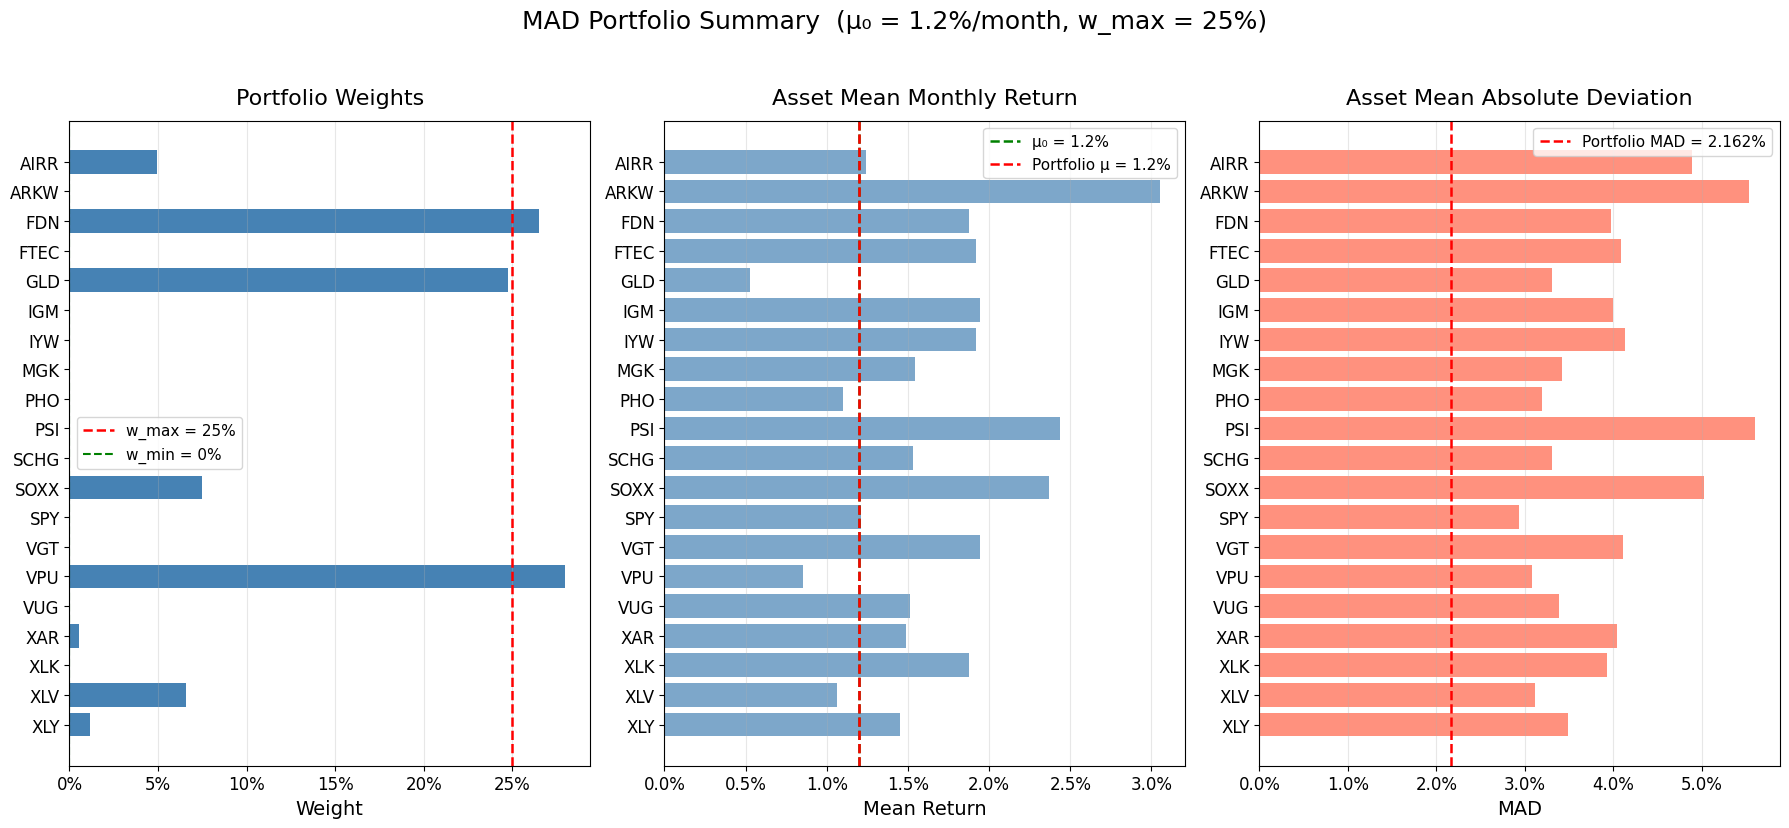

In [ ]:
# Load weights from Julia
weights_df = pd.read_csv("data\\mad_weights.csv", index_col=0)   # ETF × Weight

# Use training data
R = pd.read_csv("data\\monthly_ROR_train.csv", index_col=0)
monthly_ROR = R.T  # T_train x n
mean_ret = monthly_ROR.mean()
mad_ind  = (monthly_ROR - mean_ret).abs().mean()                                       # T × n
TARGET_MU = 0.012
W_MAX = 0.25

x_opt = weights_df["Weight"].reindex(mean_ret.index).fillna(0)
achieved_mu = float(mean_ret @ x_opt)
mad_opt = float((monthly_ROR @ x_opt - achieved_mu).abs().mean())

tickers = list(mean_ret.index)
rev = tickers[::-1]

# Font sizes
TITLE_SIZE = 16
AXIS_LABEL_SIZE = 14
TICK_SIZE = 12
LEGEND_SIZE = 11
SUPTITLE_SIZE = 18

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Panel 1: weights
bar_colors = ["steelblue" if x_opt[tkr] > 1e-4 else "lightgray" for tkr in rev]
axes[0].barh(rev, x_opt[rev], color=bar_colors)
axes[0].axvline(W_MAX, color="red", ls="--", lw=1.8, label=f"w_max = {W_MAX:.0%}")
axes[0].axvline(0.0, color="green", ls="--", lw=1.5, label="w_min = 0%")
axes[0].set_title("Portfolio Weights", fontsize=TITLE_SIZE, pad=12)
axes[0].set_xlabel("Weight", fontsize=AXIS_LABEL_SIZE)
axes[0].tick_params(axis="both", labelsize=TICK_SIZE)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[0].legend(fontsize=LEGEND_SIZE)
axes[0].grid(True, alpha=0.3, axis="x")

# Panel 2: mean return per asset
axes[1].barh(rev, mean_ret[rev], color="steelblue", alpha=0.7)
axes[1].axvline(TARGET_MU, color="green", ls="--", lw=1.8, label=f"μ₀ = {TARGET_MU:.1%}")
axes[1].axvline(achieved_mu, color="red", ls="--", lw=1.8, label=f"Portfolio μ = {achieved_mu:.1%}")
axes[1].set_title("Asset Mean Monthly Return", fontsize=TITLE_SIZE, pad=12)
axes[1].set_xlabel("Mean Return", fontsize=AXIS_LABEL_SIZE)
axes[1].tick_params(axis="both", labelsize=TICK_SIZE)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
axes[1].legend(fontsize=LEGEND_SIZE)
axes[1].grid(True, alpha=0.3, axis="x")

# Panel 3: MAD per asset
axes[2].barh(rev, mad_ind[rev], color="tomato", alpha=0.7)
axes[2].axvline(mad_opt, color="red", ls="--", lw=1.8, label=f"Portfolio MAD = {mad_opt:.3%}")
axes[2].set_title("Asset Mean Absolute Deviation", fontsize=TITLE_SIZE, pad=12)
axes[2].set_xlabel("MAD", fontsize=AXIS_LABEL_SIZE)
axes[2].tick_params(axis="both", labelsize=TICK_SIZE)
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
axes[2].legend(fontsize=LEGEND_SIZE)
axes[2].grid(True, alpha=0.3, axis="x")

fig.suptitle(
    f"MAD Portfolio Summary  μ₀ = {TARGET_MU:.1%}",
    fontsize=SUPTITLE_SIZE,
    y=1.03
)

fig.tight_layout()
fig.show()